In [1]:
import pandas as pd
import yfinance as yf
import datetime as dt

In [2]:
start=dt.datetime(2020,1,1)
end=dt.datetime(2023,12,31)
stk_data=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data.columns=stk_data.columns.get_level_values(0)

In [4]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [5]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data

Price,Open,High,Low,Close
Date,,,,
2020-01-01,675.956609,680.008790,670.390471,672.216125
2020-01-02,673.284861,686.176147,673.284861,683.660217
2020-01-03,682.636001,686.487835,678.183067,684.484009
2020-01-06,676.847322,680.365106,667.050830,668.609375
2020-01-07,676.401873,683.303975,673.952766,678.895569
...,...,...,...,...
2023-12-22,1264.550536,1275.073539,1258.646635,1267.243042
2023-12-26,1268.700379,1280.532666,1266.081931,1273.665527
2023-12-27,1275.617031,1284.460338,1271.220103,1278.013184


In [6]:
stk_data.to_csv("RELIANCE.NS.csv")

In [7]:
column="Close"

In [8]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
data1=ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (992, 1)


In [9]:
len(data1)

992

In [10]:
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
for i in orders:
    from statsmodels.tsa.arima.model import ARIMA
    model=ARIMA(data1,order=i)
    model_fit=model.fit()

    y_pred=model_fit.predict(0,len(data1)-1)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)

RMSE-Testset: 0.02127816609480784
MAPE-Testset: 303129212824.53546
RMSE-Testset: 0.02126828136549949
MAPE-Testset: 305319346763.1046


C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE-Testset: 0.025923145906001557
MAPE-Testset: 319509815096.61993
RMSE-Testset: 0.021788712986950218
MAPE-Testset: 291839982272.3015


C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


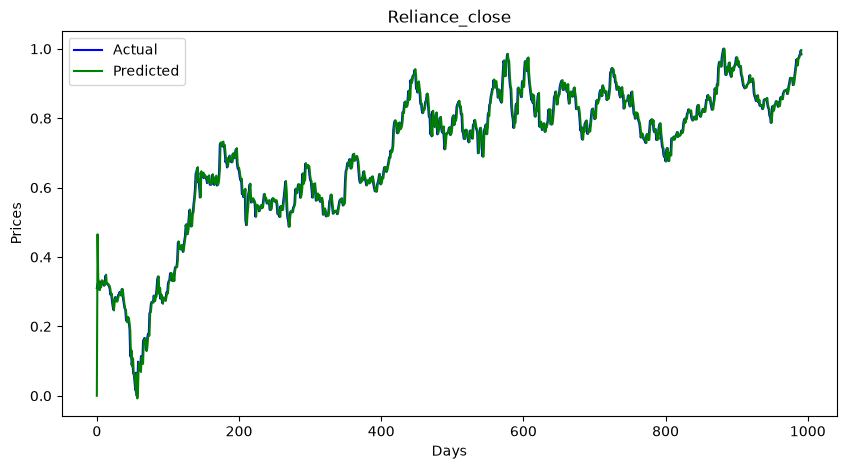

In [11]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","Reliance_close","Days","Prices")

In [12]:
from stockFunctions import conversionSingle
atestnormtable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=ms.inverse_transform(atestnormtable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["close"])

In [13]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

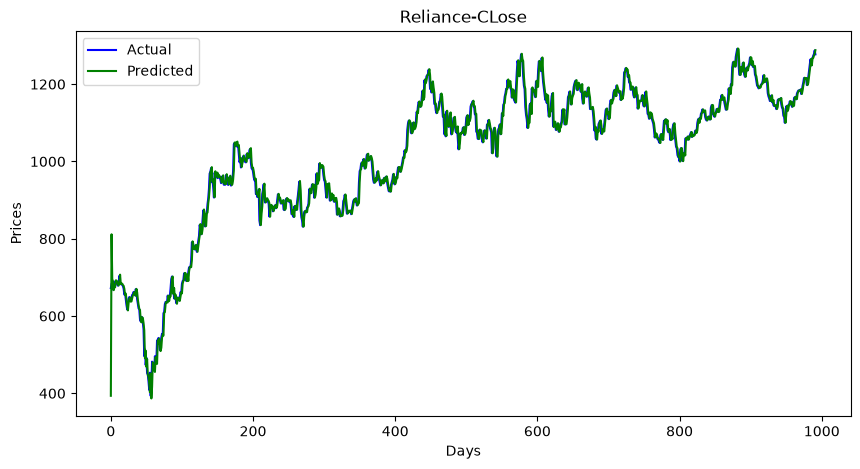

In [14]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","Reliance-CLose","Days","Prices")

In [15]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 19.558898735738435
MAPE-Testset: 0.01363958026486087


In [16]:
forecast=model_fit.predict(len(data1),len(data1)+3)

In [17]:
forecast

array([0.98469432, 0.98510407, 0.9860191 , 0.98646325])

In [18]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [20]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [21]:
forecast_stock_price_test_oriF

,Closefore
0,1277.585018
1,1277.952828
2,1278.77422
3,1279.172916
